# Practice Lab Assignment 1 – Neural Network Implementation from Scratch

## Fashion-MNIST Image Classification

### Objective
Implement a simple feedforward neural network from scratch in Python without using built-in deep learning libraries. The implementation demonstrates parameter initialization, forward propagation, backpropagation, cross-entropy loss, and gradient descent.

### Student Information
- **Name:** Shreya Dattaram Bhosale
- **PRN Number:** 202502110010
- **Class:** T.Y.B.Tech
- **Course:** Generative AI Lab
- **Department:** CSE (AI & ML)
- **Batch:** A3
- **Date of Submission:** 15/08/2026

## 1. Problem Definition

### Dataset
Fashion-MNIST is an image classification dataset containing 28 × 28 grayscale images of clothing and footwear. Each image belongs to one of 10 classes:

0. T-shirt/top  
1. Trouser  
2. Pullover  
3. Dress  
4. Coat  
5. Sandal  
6. Shirt  
7. Sneaker  
8. Bag  
9. Ankle boot

### Task
The task is a **multi-class classification problem**. The neural network receives an image containing 784 pixel values and predicts one of the 10 clothing classes.

### Why this problem?
Image classification is a suitable application for a feedforward neural network because the network can learn relationships between pixel values and class labels. Fashion-MNIST is also useful for demonstrating the complete learning process from input data to final prediction.

## 2. Libraries Used

The neural network is implemented manually using **NumPy**. TensorFlow, Keras and PyTorch are not used for the model.

Scikit-learn is used only for dataset loading, train/validation/test splitting, and evaluation metrics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

np.random.seed(42)

## 3. Load the Fashion-MNIST Dataset

In [2]:
fashion = fetch_openml(
    'Fashion-MNIST',
    version=1,
    as_frame=False,
    parser='auto'
)

X = fashion.data.astype(np.float32)
y = fashion.target.astype(np.int64)

print("Complete dataset shape:", X.shape)
print("Labels shape:", y.shape)

Complete dataset shape: (70000, 784)
Labels shape: (70000,)


## 4. Data Preprocessing

Each image has 28 × 28 = **784 pixels**.

The pixel values originally range from 0 to 255. They are normalized to the range 0 to 1.

For a practical from-scratch implementation, a stratified subset of 20,000 images is used. This keeps the training time reasonable while preserving all 10 classes. The same code can be used with the complete dataset by removing the subset step.

In [3]:
# Normalize pixel values
X = X / 255.0

# Select a balanced subset for practical from-scratch training
X_small, _, y_small, _ = train_test_split(
    X,
    y,
    train_size=20000,
    stratify=y,
    random_state=42
)

# 80% training, 10% validation, 10% testing
X_train, X_temp, y_train, y_temp = train_test_split(
    X_small,
    y_small,
    test_size=0.20,
    stratify=y_small,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training data  :", X_train.shape)
print("Validation data:", X_val.shape)
print("Testing data   :", X_test.shape)

Training data  : (16000, 784)
Validation data: (2000, 784)
Testing data   : (2000, 784)


## 5. Visualize Sample Images

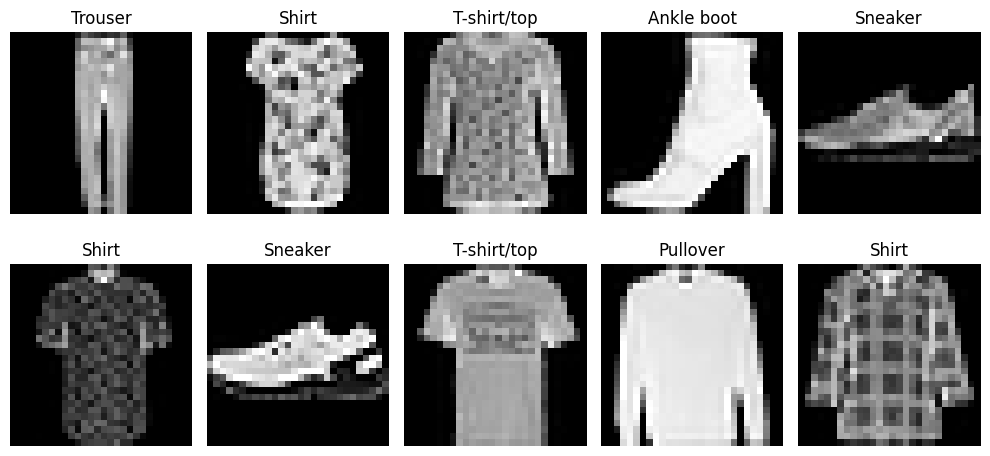

In [4]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Neural Network Architecture

The network architecture is:

**784 → 128 → 10**

- **Input layer:** 784 neurons
- **Hidden layer:** 128 neurons with ReLU activation
- **Output layer:** 10 neurons with Softmax activation

The hidden layer learns non-linear patterns from the input pixels. The output layer produces a probability for each of the 10 classes.

## 7. Number of Trainable Parameters

The number of trainable parameters is:

### First layer
784 × 128 weights + 128 biases = **100,480**

### Second layer
128 × 10 weights + 10 biases = **1,290**

### Total
**101,770 trainable parameters**

This shows that even a small feedforward network contains a large number of values that must be learned during training.

In [5]:
input_size = 784
hidden_size = 128
output_size = 10

total_parameters = (
    input_size * hidden_size + hidden_size +
    hidden_size * output_size + output_size
)

print("Total trainable parameters:", total_parameters)

Total trainable parameters: 101770


## 8. Activation Functions

### ReLU

The hidden layer uses Rectified Linear Unit:

**ReLU(x) = max(0, x)**

ReLU introduces non-linearity and is computationally simple.

### Softmax

The output layer uses Softmax:

**Softmax(zᵢ) = exp(zᵢ) / Σ exp(zⱼ)**

It converts the output scores into probabilities whose sum is 1.

In [6]:
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(np.float32)


def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

## 9. Cross-Entropy Loss

Cross-entropy is suitable for multi-class classification.

For each sample, the loss depends on the probability assigned to the correct class:

**Loss = -log(correct-class probability)**

The average loss is calculated over the complete batch.

In [7]:
def cross_entropy(y_true, y_pred):
    n = len(y_true)
    correct_prob = y_pred[np.arange(n), y_true]
    return -np.mean(np.log(correct_prob + 1e-9))

## 10. One-Hot Encoding

For backpropagation, each class label is represented as a vector of length 10. The correct class is represented by 1 and all other classes by 0.

In [8]:
def one_hot(y, classes=10):
    result = np.zeros((len(y), classes), dtype=np.float32)
    result[np.arange(len(y)), y] = 1
    return result

## 11. Parameter Initialization

Weights are initialized with He initialization because the hidden layer uses ReLU. Biases are initialized to zero.

The trainable parameters are W1, b1, W2 and b2.

In [9]:
W1 = np.random.randn(input_size, hidden_size).astype(np.float32)
W1 *= np.sqrt(2 / input_size)

b1 = np.zeros((1, hidden_size), dtype=np.float32)

W2 = np.random.randn(hidden_size, output_size).astype(np.float32)
W2 *= np.sqrt(2 / hidden_size)

b2 = np.zeros((1, output_size), dtype=np.float32)

print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)

W1: (784, 128)
b1: (1, 128)
W2: (128, 10)
b2: (1, 10)


## 12. Forward Propagation

The forward pass follows these steps:

1. Calculate the weighted sum of the input.
2. Add the bias.
3. Apply ReLU.
4. Calculate the weighted sum at the output layer.
5. Apply Softmax.
6. Obtain class probabilities.

In [10]:
def forward(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = softmax(z2)

    return z1, a1, z2, a2

## 13. Backpropagation

Backpropagation calculates the gradient of the loss with respect to every trainable parameter.

For Softmax combined with cross-entropy:

**dz2 = (predicted probability − actual one-hot label) / batch size**

The gradients are propagated from the output layer to the hidden layer and then to the input layer.

These gradients are used by gradient descent to update the parameters.

In [11]:
def backward(X, y, z1, a1, a2):
    n = len(y)
    y_hot = one_hot(y)

    # Output layer gradients
    dz2 = (a2 - y_hot) / n
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # Hidden layer gradients
    da1 = dz2 @ W2.T
    dz1 = da1 * relu_derivative(z1)

    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

## 14. Training using Mini-Batch Gradient Descent

The update rule is:

**Parameter = Parameter − Learning Rate × Gradient**

Mini-batch gradient descent is used with:

- Learning rate = 0.1
- Batch size = 128
- Epochs = 15

Training loss and accuracy are recorded after every epoch. Validation loss and accuracy are also recorded to observe generalization.

In [12]:
learning_rate = 0.1
epochs = 15
batch_size = 128

train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

for epoch in range(epochs):
    indices = np.random.permutation(len(X_train))

    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    for start in range(0, len(X_train), batch_size):
        end = start + batch_size

        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        z1, a1, z2, a2 = forward(X_batch)

        dW1, db1, dW2, db2 = backward(
            X_batch, y_batch, z1, a1, a2
        )

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

    # Training metrics
    _, _, _, train_prob = forward(X_train)
    train_loss = cross_entropy(y_train, train_prob)
    train_pred = np.argmax(train_prob, axis=1)
    train_acc = accuracy_score(y_train, train_pred)

    # Validation metrics
    _, _, _, val_prob = forward(X_val)
    val_loss = cross_entropy(y_val, val_prob)
    val_pred = np.argmax(val_prob, axis=1)
    val_acc = accuracy_score(y_val, val_pred)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 01/15 | Train Loss: 0.6687 | Train Acc: 0.7638 | Val Loss: 0.6921 | Val Acc: 0.7630
Epoch 02/15 | Train Loss: 0.6064 | Train Acc: 0.7823 | Val Loss: 0.6388 | Val Acc: 0.7710
Epoch 03/15 | Train Loss: 0.5003 | Train Acc: 0.8308 | Val Loss: 0.5356 | Val Acc: 0.8170
Epoch 04/15 | Train Loss: 0.5178 | Train Acc: 0.8081 | Val Loss: 0.5496 | Val Acc: 0.7980
Epoch 05/15 | Train Loss: 0.4476 | Train Acc: 0.8429 | Val Loss: 0.4800 | Val Acc: 0.8345
Epoch 06/15 | Train Loss: 0.4343 | Train Acc: 0.8492 | Val Loss: 0.4793 | Val Acc: 0.8390
Epoch 07/15 | Train Loss: 0.4218 | Train Acc: 0.8531 | Val Loss: 0.4716 | Val Acc: 0.8360
Epoch 08/15 | Train Loss: 0.4121 | Train Acc: 0.8534 | Val Loss: 0.4607 | Val Acc: 0.8400
Epoch 09/15 | Train Loss: 0.4034 | Train Acc: 0.8582 | Val Loss: 0.4613 | Val Acc: 0.8340
Epoch 10/15 | Train Loss: 0.3894 | Train Acc: 0.8618 | Val Loss: 0.4400 | Val Acc: 0.8440
Epoch 11/15 | Train Loss: 0.3674 | Train Acc: 0.8722 | Val Loss: 0.4235 | Val Acc: 0.8540
Epoch 12/1

## 15. Training and Validation Loss

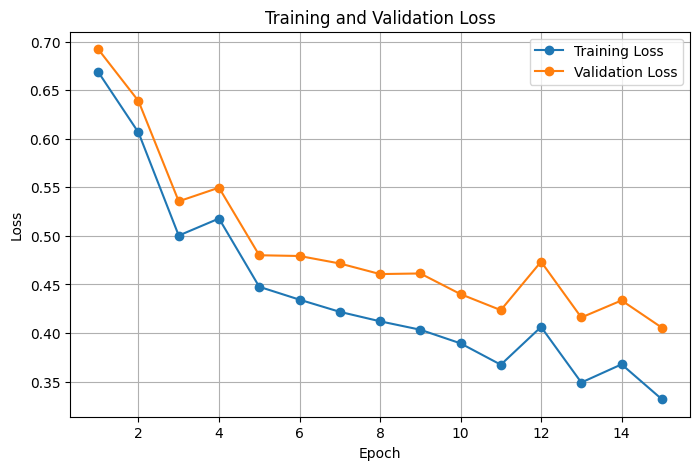

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_loss_history, marker="o", label="Training Loss")
plt.plot(range(1, epochs + 1), val_loss_history, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

## 16. Training and Validation Accuracy

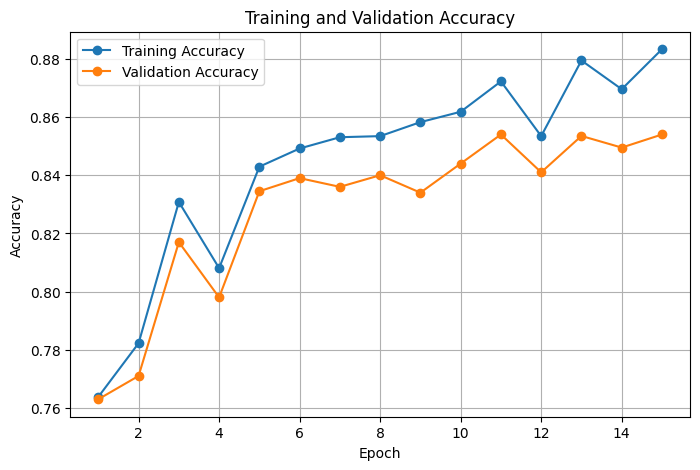

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_acc_history, marker="o", label="Training Accuracy")
plt.plot(range(1, epochs + 1), val_acc_history, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

## 17. Final Test Evaluation

The test set is kept separate from training and validation. It is used only after training is complete to estimate the model's performance on unseen data.

In [15]:
_, _, _, test_prob = forward(X_test)
y_pred = np.argmax(test_prob, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
test_recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
test_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Final Test Performance")
print("----------------------")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

Final Test Performance
----------------------
Accuracy : 0.8560
Precision: 0.8564
Recall   : 0.8560
F1-score : 0.8557


## 18. Detailed Classification Report

In [16]:
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

 T-shirt/top       0.79      0.83      0.81       200
     Trouser       0.95      0.98      0.96       200
    Pullover       0.73      0.77      0.75       200
       Dress       0.87      0.84      0.86       200
        Coat       0.80      0.73      0.77       200
      Sandal       0.94      0.93      0.93       200
       Shirt       0.66      0.65      0.65       200
     Sneaker       0.88      0.94      0.91       200
         Bag       0.97      0.96      0.97       200
  Ankle boot       0.97      0.93      0.95       200

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



## 19. Confusion Matrix

The confusion matrix shows the relationship between actual and predicted classes. Larger values along the diagonal indicate correct predictions.

Similar clothing categories may have more confusion because their visual appearance is close.

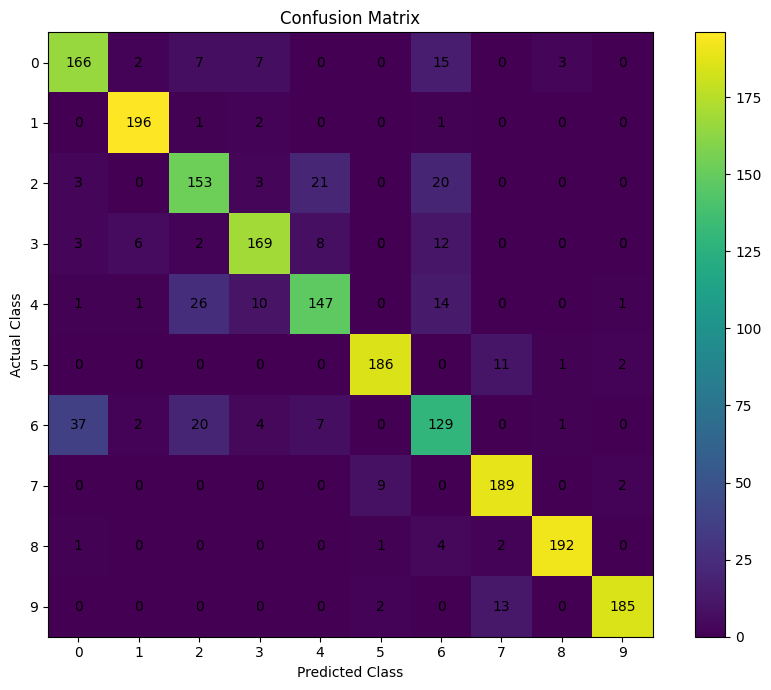

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

plt.xticks(range(10), range(10))
plt.yticks(range(10), range(10))

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 20. Sample Prediction

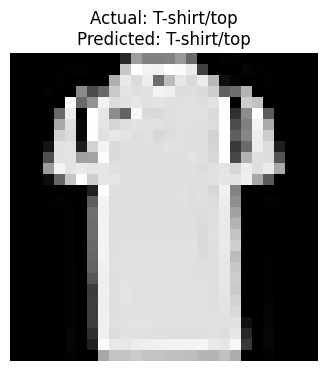

Predicted class: T-shirt/top
Actual class   : T-shirt/top
Confidence     : 0.9671


In [18]:
sample_index = 10

probabilities = test_prob[sample_index]
predicted_class = np.argmax(probabilities)
actual_class = y_test[sample_index]

plt.figure(figsize=(4, 4))
plt.imshow(X_test[sample_index].reshape(28, 28), cmap="gray")
plt.title(
    f"Actual: {class_names[actual_class]}\n"
    f"Predicted: {class_names[predicted_class]}"
)
plt.axis("off")
plt.show()

print("Predicted class:", class_names[predicted_class])
print("Actual class   :", class_names[actual_class])
print("Confidence     :", f"{probabilities[predicted_class]:.4f}")

## 21. Hyperparameter Analysis

The main training hyperparameters are learning rate, batch size and number of epochs.

### Learning Rate
A very small learning rate can make training slow. A very large learning rate can make training unstable. The selected value of 0.1 provides a practical starting point for this implementation.

### Batch Size
A batch size of 128 provides a balance between computational efficiency and stable gradient estimates.

### Number of Epochs
Fifteen epochs provide sufficient iterations to observe whether the loss decreases and the model learns meaningful patterns.

For a formal comparison, the same network can be trained with different learning rates such as 0.01, 0.05 and 0.1, while keeping the other parameters fixed.

## 22. Analysis of the Implemented Model

The implemented network demonstrates the complete learning process of a feedforward neural network without a deep-learning framework.

### Strengths
- The complete forward pass is manually implemented.
- ReLU introduces non-linearity.
- Softmax provides multi-class probabilities.
- Cross-entropy is appropriate for multi-class classification.
- Backpropagation calculates gradients manually.
- Mini-batch gradient descent updates all trainable parameters.
- Validation data is used to observe generalization.

### Limitations
- The network is fully connected and does not explicitly preserve the spatial relationship between neighboring pixels.
- Training from scratch with NumPy is slower than optimized deep-learning frameworks.
- A single hidden layer may have limited ability to learn complex visual features.
- A subset of 20,000 images is used to make from-scratch training practical.

### Suitability
The model is highly suitable for demonstrating neural-network fundamentals. However, for production-level image classification, a CNN would generally be a better architectural choice because it can learn spatial features such as edges, textures and shapes.

## 23. Comparison with Alternative Models

| Model | Main Approach | Suitability |
|---|---|---|
| Logistic Regression | Linear classification | Good baseline but limited for complex image patterns |
| Neural Network from Scratch | Fully connected network with manual backpropagation | Good for learning and demonstrating neural-network fundamentals |
| Keras/TensorFlow Neural Network | Optimized feedforward neural network | Faster and easier for practical training |
| CNN | Convolution-based spatial feature learning | More suitable for image classification |

The provided reference implementation uses Keras/TensorFlow with Flatten → Dense(128, ReLU) → Dense(10, Softmax), SGD and sparse categorical cross-entropy. This assignment implements the same core feedforward idea manually so that the internal mathematical operations are visible.

## 24. Interpretation of Results

After executing the notebook, use the actual values printed above for the final discussion.

A good training result should show:

- Training loss decreasing over epochs.
- Training accuracy increasing over epochs.
- Validation performance generally following the training trend.
- Test accuracy providing an estimate of performance on unseen images.
- Precision, recall and F1-score providing additional information about classification quality.
- The confusion matrix showing which clothing categories are easiest and hardest to distinguish.

If training accuracy becomes much higher than validation accuracy, the model may be overfitting. If both remain low, the model may be underfitting or require different hyperparameters.

## 25. Conclusion

A feedforward neural network was successfully designed for Fashion-MNIST image classification and implemented from scratch using NumPy. The model contains 784 input neurons, one hidden layer of 128 ReLU neurons and 10 Softmax output neurons.

The experiment demonstrates parameter initialization, forward propagation, loss calculation, backpropagation and mini-batch gradient descent. Training and validation curves, classification metrics, a confusion matrix and a sample prediction are used to evaluate the model.

The implementation provides a clear understanding of how neural networks learn from data without depending on built-in deep-learning libraries. Although a fully connected network is suitable for demonstrating the fundamentals, a CNN would generally be more appropriate for higher-quality image classification because it can exploit spatial image structure.

## 26. Declaration

I, **Shreya Dattaram Bhosale**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines.

**GitHub Repository Link:** ______________________________

**Signature:** Shreya Dattaram Bhosale